# Ergebnis — iOCV  ·  FUDS  ·  Realdaten



## Imports

In [1]:
import pydpeet as eet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pydpeet.process.analyze.extract.haf_cell_fitting import (
    get_best_half_cell_fit,
    fit_half_cells,
    plot_half_cell_match,
    dir_anode,
    dir_cathode,
)

from pydpeet.process.analyze.extract.lithium_amount import calculate_electrode_quantities
from pydpeet.process.analyze.extract.lli_lam import calculate_lli_lam

# Anker-Erzeugung (Pausen -> Ruhespannungen)
from pydpeet.process.analyze.extract.pauses import extract_pauses
from pydpeet.process.analyze.extract.ocv_simple import pauses_to_ocv_simple

# Kapazitaet + LLI/LAM ueber den gemeinsam abgedeckten SOC-Bereich
from pydpeet.process.analyze.extract.capa_covered import (
    lli_lam_covered,
    estimate_capacity_covered_mAh,
    covered_soc_range,
)
from pydpeet.process.analyze.extract.capa_curvefit import build_full_cell_ocv_curve

eet.set_logging_style("ERROR")


PATH_B1 = "../../..input_data/Input_files_checkup/20231129133302-CheckUp-3-7-AM23NMC00020.xlsx"
PATH_B2 = "../../..input_data/Input_files_checkup/20240216101054-CheckUp-3-8-AM23NMC00020.xlsx"


CSV_PATH = "../../..input_data/Felddaten/vin38.csv"

---
# Sektion A — iOCV


### A.1) Einlesen und Aufbereiten

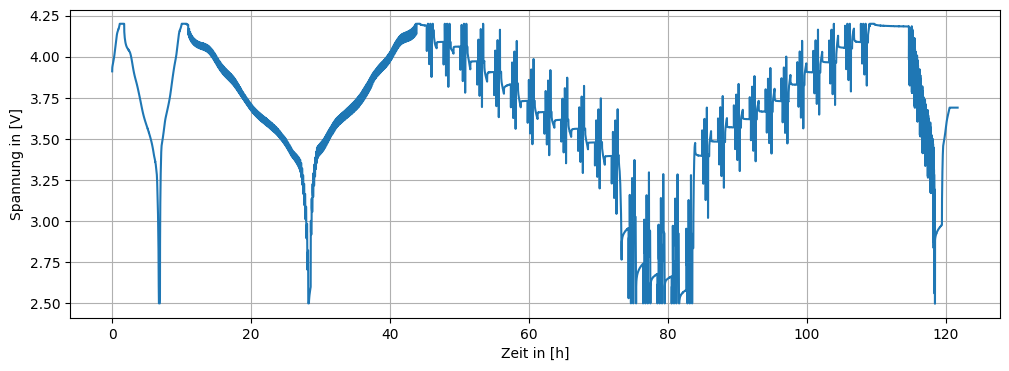

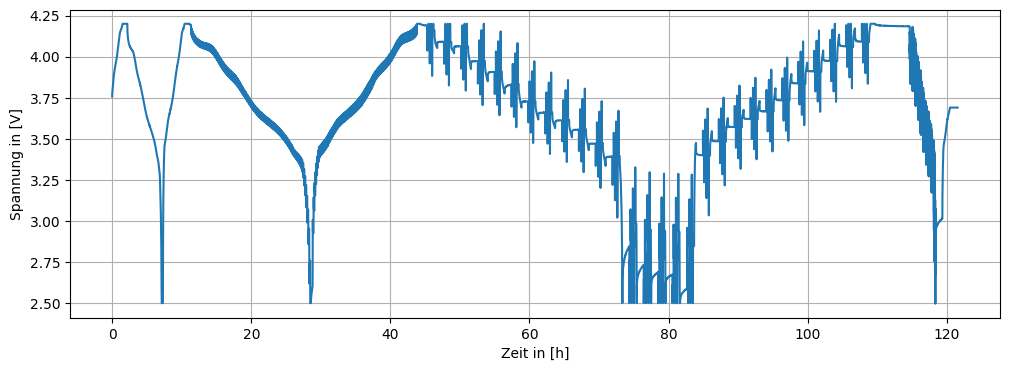

In [40]:
df_raw_1_iocv = eet.read(config="neware_8_0_0_516", input_path=PATH_B1)
df_raw_2_iocv = eet.read(config="neware_8_0_0_516", input_path=PATH_B2)

df_seq_1_iocv = eet.add_primitive_segments(df_raw_1_iocv)
df_seq_2_iocv = eet.add_primitive_segments(df_raw_2_iocv)

df_cap_1_iocv = eet.add_capacity(df_raw_1_iocv, df_seq_1_iocv, neware_bool=True, config=eet.lgm50lt_nmc_4800)
df_cap_2_iocv = eet.add_capacity(df_raw_2_iocv, df_seq_2_iocv, neware_bool=True, config=eet.lgm50lt_nmc_4800)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_raw_1_iocv["Test_Time[s]"] / 3600, df_raw_1_iocv["Voltage[V]"])
ax.grid(True)
ax.set_xlabel("Zeit in [h]")
ax.set_ylabel("Spannung in [V]")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_raw_2_iocv["Test_Time[s]"] / 3600, df_raw_2_iocv["Voltage[V]"])
ax.grid(True)
ax.set_xlabel("Zeit in [h]")
ax.set_ylabel("Spannung in [V]")
plt.show()


### A.2) iOCV-Phasen extrahieren und auf Charge filtern

In [41]:
df_ocv_1 = eet.extract_ocv_iocv(df=df_cap_1_iocv, config=eet.lgm50lt_nmc_4800, visualize=False)
df_ocv_2 = eet.extract_ocv_iocv(df=df_cap_2_iocv, config=eet.lgm50lt_nmc_4800, visualize=False)

dpf_1 = pd.concat(df_ocv_1, ignore_index=True)
dpf_1 = dpf_1.loc[:, ~dpf_1.columns.duplicated()]
df_charge_1 = dpf_1[dpf_1["iOCV_type"] == "Charge"]

dpf_2 = pd.concat(df_ocv_2, ignore_index=True)
dpf_2 = dpf_2.loc[:, ~dpf_2.columns.duplicated()]
df_charge_2 = dpf_2[dpf_2["iOCV_type"] == "Charge"]

print(f"B1 Charge-iOCV: {len(df_charge_1)} Samples, SOC {df_charge_1['SOC'].min():.2f}–{df_charge_1['SOC'].max():.2f}")
print(f"B2 Charge-iOCV: {len(df_charge_2)} Samples, SOC {df_charge_2['SOC'].min():.2f}–{df_charge_2['SOC'].max():.2f}")


B1 Charge-iOCV: 121 Samples, SOC 0.00–1.00
B2 Charge-iOCV: 119 Samples, SOC 0.00–0.97


### A.3) Halbzellen-Fit auf B1 und B2

In [42]:
best_fit_iocv_1 = get_best_half_cell_fit(df_charge_1, full_cell_name="iOCV_B1")
best_fit_iocv_2 = get_best_half_cell_fit(df_charge_2, full_cell_name="iOCV_B2")

print("B1 (Referenz, frisch):")
print(best_fit_iocv_1[["RMSE[mV]", "Anode", "Cathode",
                       "Sol_Anode_Min", "Sol_Anode_Max",
                       "Sol_Cathode_Min", "Sol_Cathode_Max"]].T)
print("\nB2 (gealtert):")
print(best_fit_iocv_2[["RMSE[mV]", "Anode", "Cathode",
                       "Sol_Anode_Min", "Sol_Anode_Max",
                       "Sol_Cathode_Min", "Sol_Cathode_Max"]].T)


B1 (Referenz, frisch):
                                       0
RMSE[mV]                       13.368696
Anode            Graphite, Ecker2015.csv
Cathode             NMC811, Chen2020.csv
Sol_Anode_Min                   0.001515
Sol_Anode_Max                        1.0
Sol_Cathode_Min                 0.266907
Sol_Cathode_Max                 0.845409

B2 (gealtert):
                                       0
RMSE[mV]                       13.509451
Anode            Graphite, Ecker2015.csv
Cathode             NMC811, Chen2020.csv
Sol_Anode_Min                   0.002343
Sol_Anode_Max                        1.0
Sol_Cathode_Min                 0.260988
Sol_Cathode_Max                 0.847454


### A.4) Half-Cell-Plots der iOCV-Fits

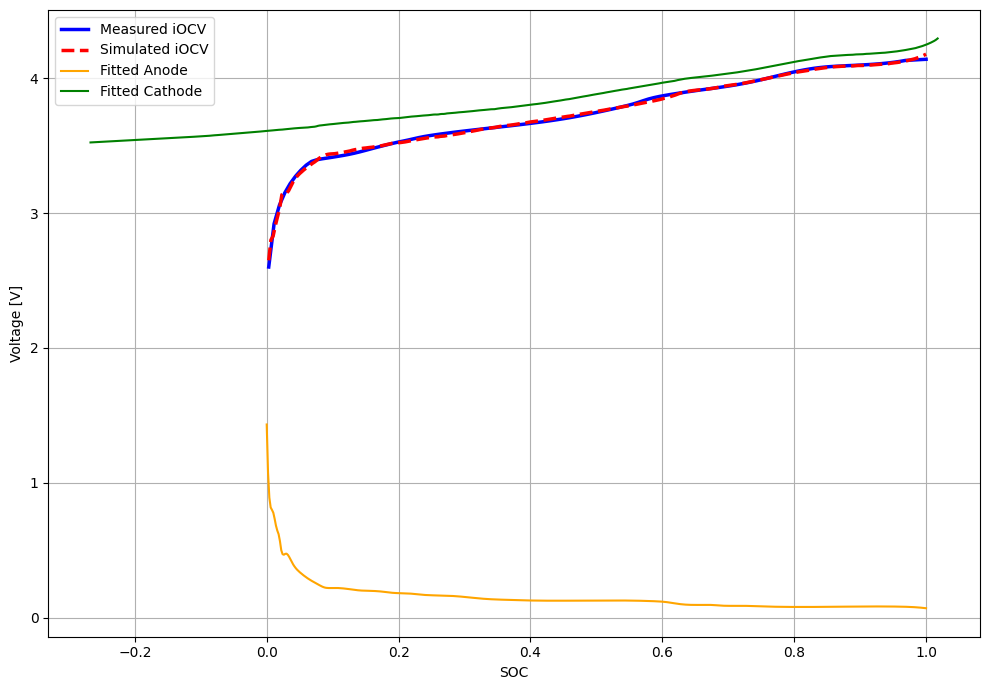

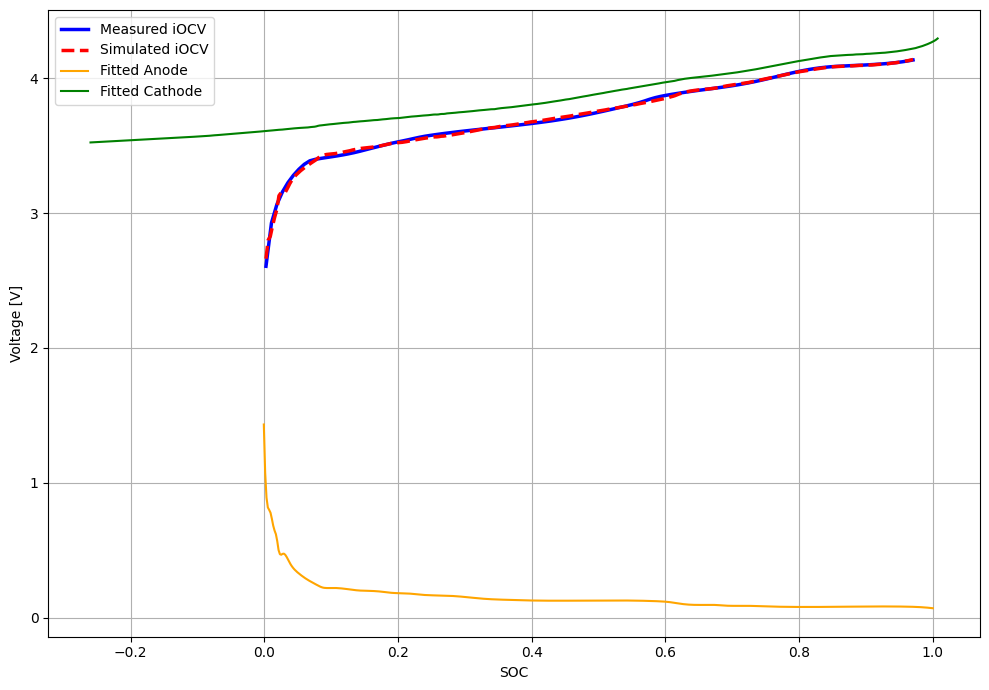

In [43]:
for label, best_fit, df_charge in [("B1", best_fit_iocv_1, df_charge_1),
                                    ("B2", best_fit_iocv_2, df_charge_2)]:
    anode_raw   = pd.read_csv(f"{dir_anode}/{best_fit['Anode'].iloc[0]}")
    cathode_raw = pd.read_csv(f"{dir_cathode}/{best_fit['Cathode'].iloc[0]}")
    plot_half_cell_match(
        full_df       = df_charge,
        anode_df      = anode_raw,
        cathode_df    = cathode_raw,
        solution_array= best_fit["Solution_Array"].iloc[0],
        filename      = f"BestMatch_iOCV_{label}.png",
    )


### A.5) Kapazität, Elektroden-Größen und LLI / LAM

In [44]:
# Kapazitaet + LLI/LAM ueber den gemeinsam abgedeckten SOC-Bereich (capa_covered)
def iocv_state(df_cap, df_charge, best_fit):
    t0, t1 = df_charge["Test_Time[s]"].min(), df_charge["Test_Time[s]"].max()
    seg = df_cap[(df_cap["Test_Time[s]"] >= t0) & (df_cap["Test_Time[s]"] <= t1)]
    anchors = pauses_to_ocv_simple(extract_pauses(seg, min_pause_duration_s=60))
    return {
        "df":         seg,
        "anchors":    anchors,
        "fit_result": best_fit,
        "anode_df":   pd.read_csv(f"{dir_anode}/{best_fit['Anode'].iloc[0]}"),
        "cathode_df": pd.read_csv(f"{dir_cathode}/{best_fit['Cathode'].iloc[0]}"),
    }

ref_state_iocv  = iocv_state(df_cap_1_iocv, df_charge_1, best_fit_iocv_1)
aged_state_iocv = iocv_state(df_cap_2_iocv, df_charge_2, best_fit_iocv_2)
lli_lam_iocv = lli_lam_covered(ref_state_iocv, aged_state_iocv)

cap_iocv_1 = lli_lam_iocv["Full_Cell_Cap_ref_mAh"].iloc[0]
cap_iocv_2 = lli_lam_iocv["Full_Cell_Cap_mAh"].iloc[0]
print(f"B1: {cap_iocv_1:8.1f} mAh   B2: {cap_iocv_2:8.1f} mAh")
print(f"gemeinsames SOC-Fenster: {lli_lam_iocv['SOC_window_lo'].iloc[0]:.3f} .. {lli_lam_iocv['SOC_window_hi'].iloc[0]:.3f}")

print("\nLLI / LAM (iOCV, B1 -> B2), im gemeinsamen SOC-Fenster gemessen:")
print(lli_lam_iocv[[
    "Full_Cell_Cap_ref_mAh", "Full_Cell_Cap_mAh", "SOH_pct",
    "LLI_mAh", "LLI_pct",
    "LAM_Anode_mAh", "LAM_Anode_pct",
    "LAM_Cathode_mAh", "LAM_Cathode_pct",
]].round(2).T)


B1:   4243.0 mAh   B2:   4239.8 mAh
gemeinsames SOC-Fenster: 0.014 .. 0.967

LLI / LAM (iOCV, B1 -> B2), im gemeinsamen SOC-Fenster gemessen:
                             0
Full_Cell_Cap_ref_mAh  4243.03
Full_Cell_Cap_mAh      4239.80
SOH_pct                  99.92
LLI_mAh                  70.56
LLI_pct                   1.14
LAM_Anode_mAh            -0.29
LAM_Anode_pct            -0.01
LAM_Cathode_mAh         105.11
LAM_Cathode_pct           1.43


---
# Sektion B — FUDS


### B.1) SOC ergänzen und FUDS-Phase extrahieren

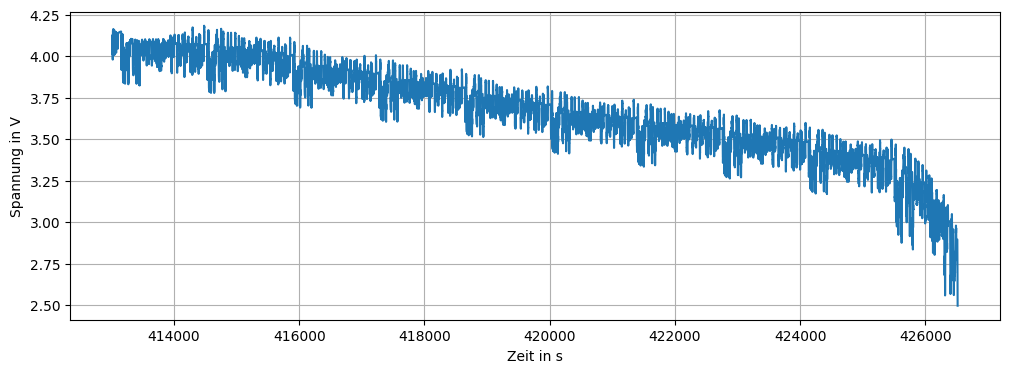

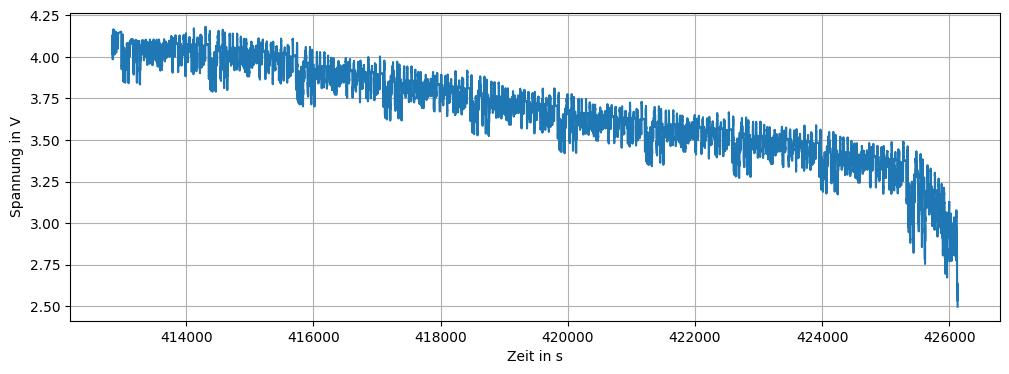

In [45]:
from pydpeet.process.analyze.extract.fuds import extract_fuds
from pydpeet.process.analyze.extract.pauses import extract_pauses
from pydpeet.process.analyze.extract.ocv_simple import pauses_to_ocv_simple

# SOC ist Voraussetzung für extract_fuds und für die Anchor-Erstellung
df_soc_1_fuds = eet.add_soc(df_raw_1_iocv, df_seq_1_iocv,
                            standard_method=eet.SocMethod.WITH_RESET_WHEN_FULL_AND_EMPTY,
                            config=eet.lgm50lt_nmc_4800)
df_soc_2_fuds = eet.add_soc(df_raw_2_iocv, df_seq_2_iocv,
                            standard_method=eet.SocMethod.WITH_RESET_WHEN_FULL_AND_EMPTY,
                            config=eet.lgm50lt_nmc_4800)

df_fuds_1 = extract_fuds(df_soc_1_fuds)
df_fuds_2 = extract_fuds(df_soc_2_fuds)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_fuds_1["Test_Time[s]"], df_fuds_1["Voltage[V]"])
ax.grid(True)
ax.set_xlabel("Zeit in s")
ax.set_ylabel("Spannung in V")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_fuds_2["Test_Time[s]"], df_fuds_2["Voltage[V]"])
ax.grid(True)
ax.set_xlabel("Zeit in s")
ax.set_ylabel("Spannung in V")
plt.show()


### B.2) Pausen → OCV-Anchors → Half-Cell-Fit

In [46]:
results_fuds = {}

for label, df_fuds in [("B1", df_fuds_1), ("B2", df_fuds_2)]:
    df_pause = extract_pauses(df_fuds, min_pause_duration_s=10)
    anchors  = pauses_to_ocv_simple(df_pause)

    df_for_fit = (
        anchors[["SOC", "U"]].rename(columns={"U": "Voltage[V]"})
               .dropna().sort_values("SOC").drop_duplicates(subset="SOC").reset_index(drop=True)
    )

    best = get_best_half_cell_fit(df_for_fit, full_cell_name=f"FUDS_{label}")
    results_fuds[label] = {"df_for_fit": df_for_fit, "best": best, "n_pauses": len(df_pause), "n_anchors": len(anchors)}

    print(f"FUDS {label}: {len(df_pause)} Pausen → {len(anchors)} Anchors → RMSE {best['RMSE[mV]'].iloc[0]:.2f} mV")
    print(best[["Anode", "Cathode",
                "Sol_Anode_Min", "Sol_Anode_Max",
                "Sol_Cathode_Min", "Sol_Cathode_Max"]].T)
    print()


FUDS B1: 116 Pausen → 116 Anchors → RMSE 8.29 mV
                                           0
Anode            Graphite, Chaouachi2021.csv
Cathode                 NMC811, Chen2020.csv
Sol_Anode_Min                       0.026223
Sol_Anode_Max                       0.707163
Sol_Cathode_Min                     0.263214
Sol_Cathode_Max                     0.877879

FUDS B2: 114 Pausen → 114 Anchors → RMSE 8.11 mV
                                           0
Anode            Graphite, Chaouachi2021.csv
Cathode                 NMC811, Chen2020.csv
Sol_Anode_Min                       0.027555
Sol_Anode_Max                       0.712395
Sol_Cathode_Min                     0.262371
Sol_Cathode_Max                     0.874124



### B.3) Half-Cell-Plots der FUDS-Fits

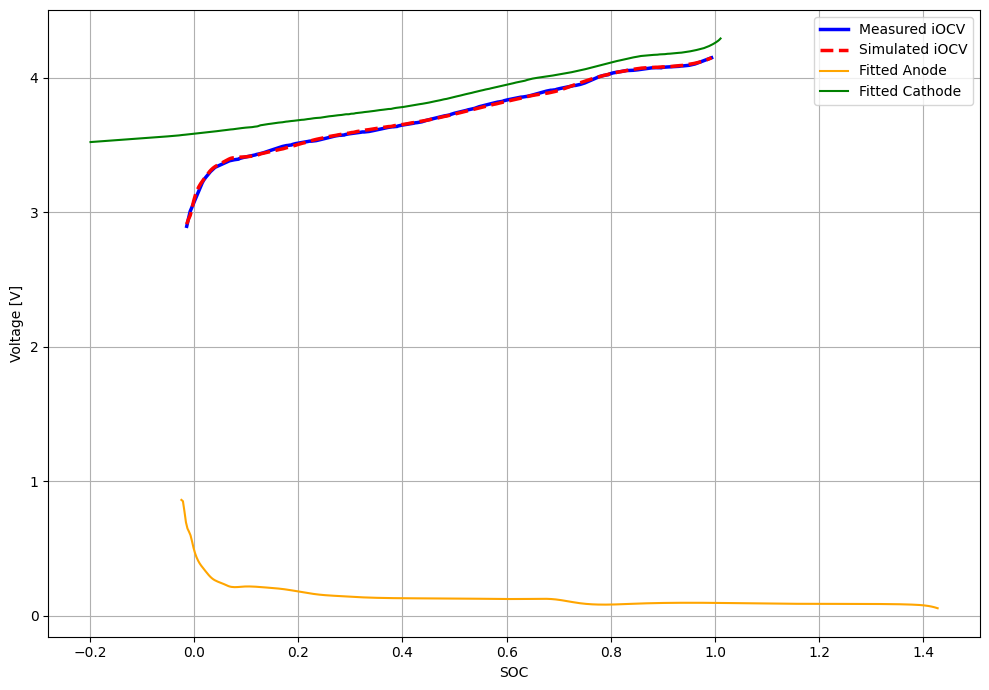

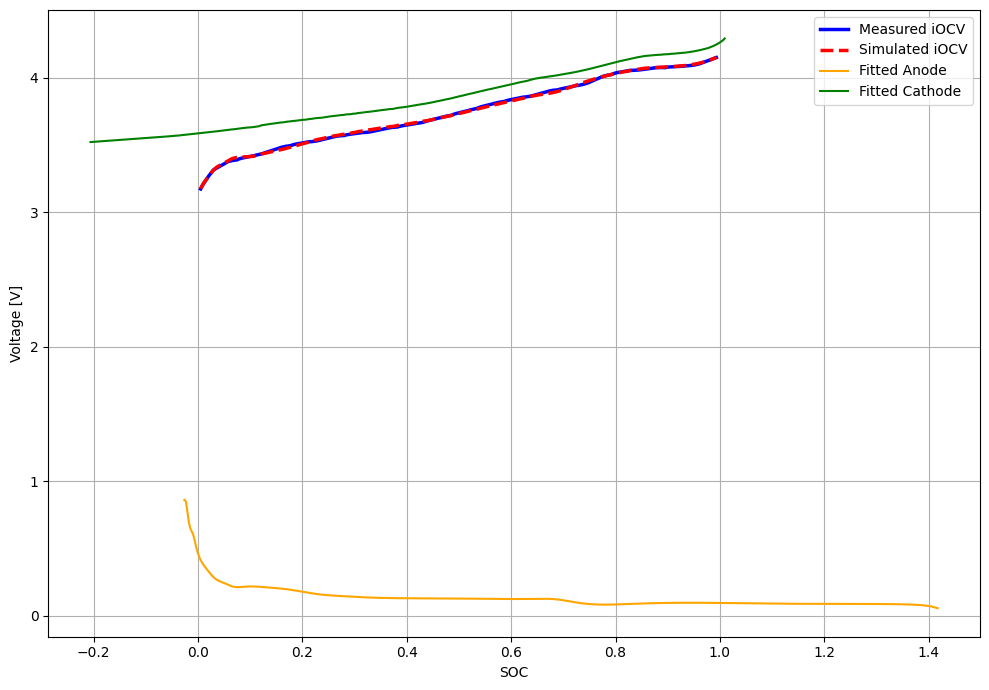

In [47]:
for label, r in results_fuds.items():
    anode_raw   = pd.read_csv(f"{dir_anode}/{r['best']['Anode'].iloc[0]}")
    cathode_raw = pd.read_csv(f"{dir_cathode}/{r['best']['Cathode'].iloc[0]}")
    plot_half_cell_match(
        full_df       = r["df_for_fit"],
        anode_df      = anode_raw,
        cathode_df    = cathode_raw,
        solution_array= r["best"]["Solution_Array"].iloc[0],
        filename      = f"BestMatch_FUDS_{label}.png",
    )


### B.4) Kapazität, Elektroden-Größen und LLI / LAM

In [48]:
# Kapazitaet + LLI/LAM (FUDS) ueber das gemeinsam abgedeckte SOC-Fenster
def fuds_state(df_fuds, best):
    anchors = pauses_to_ocv_simple(extract_pauses(df_fuds, min_pause_duration_s=10))
    return {
        "df":         df_fuds,
        "anchors":    anchors,
        "fit_result": best,
        "anode_df":   pd.read_csv(f"{dir_anode}/{best['Anode'].iloc[0]}"),
        "cathode_df": pd.read_csv(f"{dir_cathode}/{best['Cathode'].iloc[0]}"),
    }

ref_state_fuds  = fuds_state(df_fuds_1, results_fuds["B1"]["best"])
aged_state_fuds = fuds_state(df_fuds_2, results_fuds["B2"]["best"])
lli_lam_fuds = lli_lam_covered(ref_state_fuds, aged_state_fuds)

cap_fuds_1 = lli_lam_fuds["Full_Cell_Cap_ref_mAh"].iloc[0]
cap_fuds_2 = lli_lam_fuds["Full_Cell_Cap_mAh"].iloc[0]
print(f"B1: {cap_fuds_1:8.1f} mAh   B2: {cap_fuds_2:8.1f} mAh")
print(f"gemeinsames SOC-Fenster: {lli_lam_fuds['SOC_window_lo'].iloc[0]:.3f} .. {lli_lam_fuds['SOC_window_hi'].iloc[0]:.3f}")

print("\nLLI / LAM (FUDS, B1 -> B2), im gemeinsamen SOC-Fenster gemessen:")
print(lli_lam_fuds[[
    "Full_Cell_Cap_ref_mAh", "Full_Cell_Cap_mAh", "SOH_pct",
    "LLI_mAh", "LLI_pct",
    "LAM_Anode_mAh", "LAM_Anode_pct",
    "LAM_Cathode_mAh", "LAM_Cathode_pct",
]].round(2).T)


B1:   4485.1 mAh   B2:   4302.4 mAh
gemeinsames SOC-Fenster: 0.005 .. 0.992

LLI / LAM (FUDS, B1 -> B2), im gemeinsamen SOC-Fenster gemessen:
                             0
Full_Cell_Cap_ref_mAh  4485.14
Full_Cell_Cap_mAh      4302.41
SOH_pct                  95.93
LLI_mAh                 257.76
LLI_pct                   3.92
LAM_Anode_mAh           304.34
LAM_Anode_pct             4.62
LAM_Cathode_mAh         263.97
LAM_Cathode_pct           3.62


### B.5) Vergleich iOCV vs FUDS


In [49]:
vergleich = pd.DataFrame({
    "iOCV":  lli_lam_iocv[["SOH_pct", "LLI_pct", "LAM_Anode_pct", "LAM_Cathode_pct"]].iloc[0],
    "FUDS":  lli_lam_fuds[["SOH_pct", "LLI_pct", "LAM_Anode_pct", "LAM_Cathode_pct"]].iloc[0],
})
vergleich["Δ (FUDS − iOCV) [Pp]"] = vergleich["FUDS"] - vergleich["iOCV"]
print("Methoden-Vergleich B1 → B2:")
print(vergleich.round(2))


Methoden-Vergleich B1 → B2:
                  iOCV   FUDS  Δ (FUDS − iOCV) [Pp]
SOH_pct          99.92  95.93                 -4.00
LLI_pct           1.14   3.92                  2.78
LAM_Anode_pct    -0.01   4.62                  4.63
LAM_Cathode_pct   1.43   3.62                  2.18


### B.6) Vergleich über fixierte Elektrodenpaare (einheitliche Chemie)



In [50]:
# Kreuz-Fits: jede Stufe mit dem Gewinner-Paar der jeweils anderen Stufe
anode_iocv_name = best_fit_iocv_1['Anode'].iloc[0]              # iOCV-Gewinner (Ecker2015)
anode_fuds_name = results_fuds['B1']['best']['Anode'].iloc[0]   # FUDS-Gewinner (Chaouachi2021)
cathode_name    = best_fit_iocv_1['Cathode'].iloc[0]            # NMC811, Chen2020 (beide Stufen)

anode_iocv_df = pd.read_csv(f'{dir_anode}/{anode_iocv_name}')
anode_fuds_df = pd.read_csv(f'{dir_anode}/{anode_fuds_name}')
cathode_df_x  = pd.read_csv(f'{dir_cathode}/{cathode_name}')

# iOCV mit der FUDS-Anode (Chaouachi) fixiert
fit_iocv_fix_1 = fit_half_cells(df_charge_1, anode_fuds_df, cathode_df_x,
                                anode_name=anode_fuds_name, cathode_name=cathode_name,
                                full_cell_name='iOCV_B1_fix')
fit_iocv_fix_2 = fit_half_cells(df_charge_2, anode_fuds_df, cathode_df_x,
                                anode_name=anode_fuds_name, cathode_name=cathode_name,
                                full_cell_name='iOCV_B2_fix')

# FUDS mit der iOCV-Anode (Ecker) fixiert
fit_fuds_fix_1 = fit_half_cells(results_fuds['B1']['df_for_fit'], anode_iocv_df, cathode_df_x,
                                anode_name=anode_iocv_name, cathode_name=cathode_name,
                                full_cell_name='FUDS_B1_fix')
fit_fuds_fix_2 = fit_half_cells(results_fuds['B2']['df_for_fit'], anode_iocv_df, cathode_df_x,
                                anode_name=anode_iocv_name, cathode_name=cathode_name,
                                full_cell_name='FUDS_B2_fix')

for name, fit in [('iOCV B1 (Anode Chaouachi)', fit_iocv_fix_1),
                  ('iOCV B2 (Anode Chaouachi)', fit_iocv_fix_2),
                  ('FUDS B1 (Anode Ecker)',     fit_fuds_fix_1),
                  ('FUDS B2 (Anode Ecker)',     fit_fuds_fix_2)]:
    print(f"{name}: RMSE {fit['RMSE[mV]'].iloc[0]:6.2f} mV | "
          f"a_min {fit['Sol_Anode_Min'].iloc[0]:.4f}  a_max {fit['Sol_Anode_Max'].iloc[0]:.4f}  "
          f"c_min {fit['Sol_Cathode_Min'].iloc[0]:.4f}  c_max {fit['Sol_Cathode_Max'].iloc[0]:.4f}")


iOCV B1 (Anode Chaouachi): RMSE  17.06 mV | a_min 0.0097  a_max 0.7315  c_min 0.2573  c_max 0.8586
iOCV B2 (Anode Chaouachi): RMSE  15.39 mV | a_min 0.0097  a_max 0.7720  c_min 0.2567  c_max 0.8604
FUDS B1 (Anode Ecker): RMSE   9.94 mV | a_min 0.0287  a_max 1.0000  c_min 0.2744  c_max 0.8753
FUDS B2 (Anode Ecker): RMSE   9.19 mV | a_min 0.0347  a_max 0.8971  c_min 0.2682  c_max 0.8661


In [51]:
# Kapazitaet + LLI/LAM der fixierten Varianten (gleiche covered-Methode wie A.5/B.4)
ref_iocv_fix  = iocv_state(df_cap_1_iocv, df_charge_1, fit_iocv_fix_1)
aged_iocv_fix = iocv_state(df_cap_2_iocv, df_charge_2, fit_iocv_fix_2)
lli_lam_iocv_fix = lli_lam_covered(ref_iocv_fix, aged_iocv_fix)

ref_fuds_fix  = fuds_state(df_fuds_1, fit_fuds_fix_1)
aged_fuds_fix = fuds_state(df_fuds_2, fit_fuds_fix_2)
lli_lam_fuds_fix = lli_lam_covered(ref_fuds_fix, aged_fuds_fix)

print('iOCV fixiert (Chaouachi):  '
      f"B1 {lli_lam_iocv_fix['Full_Cell_Cap_ref_mAh'].iloc[0]:7.1f} mAh   "
      f"B2 {lli_lam_iocv_fix['Full_Cell_Cap_mAh'].iloc[0]:7.1f} mAh   "
      f"SOH {lli_lam_iocv_fix['SOH_pct'].iloc[0]:6.2f} %")
print('FUDS fixiert (Ecker):      '
      f"B1 {lli_lam_fuds_fix['Full_Cell_Cap_ref_mAh'].iloc[0]:7.1f} mAh   "
      f"B2 {lli_lam_fuds_fix['Full_Cell_Cap_mAh'].iloc[0]:7.1f} mAh   "
      f"SOH {lli_lam_fuds_fix['SOH_pct'].iloc[0]:6.2f} %")


iOCV fixiert (Chaouachi):  B1  4374.9 mAh   B2  4181.0 mAh   SOH  95.57 %
FUDS fixiert (Ecker):      B1  4239.9 mAh   B2  4091.3 mAh   SOH  96.50 %


In [52]:

_idx = ['SOH_pct', 'LLI_pct', 'LAM_Anode_pct', 'LAM_Cathode_pct']
def _col(res):
    return [res[k].iloc[0] for k in _idx]

vergleich_rahmen = pd.DataFrame({
    'iOCV frei (Ecker)':        _col(lli_lam_iocv),
    'FUDS fixiert (Ecker)':     _col(lli_lam_fuds_fix),
    'iOCV fixiert (Chaouachi)': _col(lli_lam_iocv_fix),
    'FUDS frei (Chaouachi)':    _col(lli_lam_fuds),
}, index=_idx).round(2)
vergleich_rahmen


,iOCV frei (Ecker),FUDS fixiert (Ecker),iOCV fixiert (Chaouachi),FUDS frei (Chaouachi)
SOH_pct,99.92,96.50,95.57,95.93
LLI_pct,1.14,3.33,4.65,3.92
LAM_Anode_pct,-0.01,-8.67,9.51,4.62
LAM_Cathode_pct,1.43,3.00,4.80,3.62


---
# Sektion C — Realdaten

### C.1) Imports und Konfiguration

In [53]:
from pydpeet.process.analyze.extract.field_data_loader import (
    load_field_data_csv,
    split_by_time_window,
)
from pydpeet.process.analyze.extract.fit_real_data import fit_real_data

NROWS                  = None
WINDOW_DAYS            = 30
MIN_PAUSE_S            = 600
MIN_POINTS_PER_CHUNK   = 20
MAX_RMSE_MV            = 50.0


MIN_DSOC_PAIR          = 0.02        
MAX_CYCLING_RATIO      = 2.0         


SOC_COVERAGE_MIN       = 0.60        
CAP_MAD_K              = 3.0         

### C.2) Roh-CSV laden und in 30-Tage-Chunks zerlegen

In [54]:
df_field = load_field_data_csv(CSV_PATH, nrows=NROWS)
print(f"Geladen: {len(df_field):,} samples, {df_field['Test_Time[s]'].iloc[-1]/86400:.1f} Tage")

chunks = split_by_time_window(df_field, window_days=WINDOW_DAYS)
print(f"{len(chunks)} Chunks ({WINDOW_DAYS} Tage je Fenster)")


Geladen: 4,132,658 samples, 939.8 Tage
32 Chunks (30 Tage je Fenster)


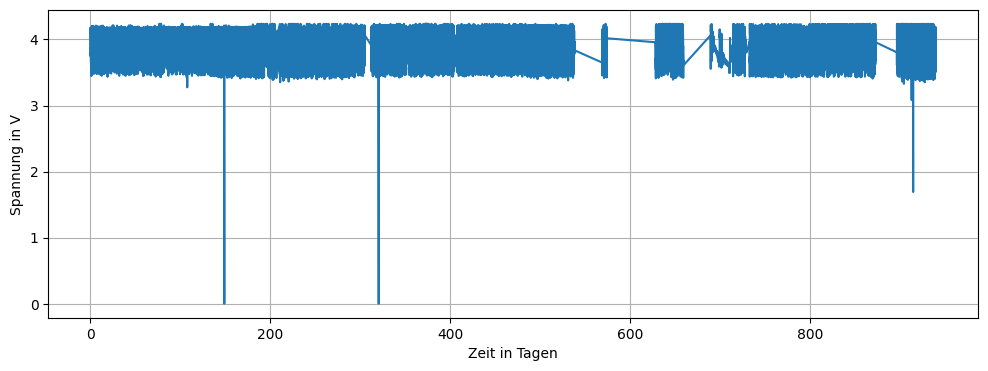

In [55]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_field["Test_Time[s]"] / 86400, df_field["Voltage[V]"])
ax.grid(True)
ax.set_xlabel("Zeit in Tagen")
ax.set_ylabel("Spannung in V")
plt.show()

### C.3) Konsens-Halbzellen-Paar über alle Chunks finden

In [56]:
consensus = fit_real_data(
    df_field,
    window_days=WINDOW_DAYS,
    min_pause_duration_s=MIN_PAUSE_S,
    min_points=MIN_POINTS_PER_CHUNK,
    max_rmse_mv=MAX_RMSE_MV,
)
print(consensus.head())

top = consensus.iloc[0]
anode_df   = pd.read_csv(f"{dir_anode}/{top['Anode']}")
cathode_df = pd.read_csv(f"{dir_cathode}/{top['Cathode']}")
print(f"\nFittingPaar:  {top['Anode']}   +   {top['Cathode']}")
print(f"  median RMSE = {top['median_rmse']:.1f} mV  über {top['n_chunks']} Chunks  ({top['wins']} Siege)")


chunk  1: nur 17 OCV-Punkte → übersprungen
chunk  2: nur 19 OCV-Punkte → übersprungen
chunk  3: nur 15 OCV-Punkte → übersprungen
chunk 10: nur 19 OCV-Punkte → übersprungen
chunk 17: nur 17 OCV-Punkte → übersprungen
chunk 18: nur 5 OCV-Punkte → übersprungen
chunk 19: nur 4 OCV-Punkte → übersprungen
chunk 20: nur 4 OCV-Punkte → übersprungen
chunk 22: nur 3 OCV-Punkte → übersprungen
chunk 29: nur 10 OCV-Punkte → übersprungen
chunk 31: nur 13 OCV-Punkte → übersprungen
chunk  4:  28 Punkte → fit OK
chunk  9:  30 Punkte → fit OK
chunk  7:  27 Punkte → fit OK
chunk 14:  29 Punkte → fit OK
chunk  8:  32 Punkte → fit OK
chunk 11:  28 Punkte → fit OK
chunk  0:  32 Punkte → fit OK
chunk 12:  25 Punkte → fit OK
chunk  6:  22 Punkte → fit OK
chunk  5:  23 Punkte → fit OK
chunk 15:  34 Punkte → fit OK
chunk 13:  34 Punkte → fit OK
chunk 16:  30 Punkte → fit OK
chunk 30:  27 Punkte → fit OK
chunk 24:  36 Punkte → fit OK
chunk 25:  31 Punkte → fit OK
chunk 26:  35 Punkte → fit OK
chunk 23:  46 Punkte 

### C.4) Per-Chunk-Pipeline (covered, globales SOC-Fenster, Plausibilitätsfilter)


In [57]:
from pydpeet.process.analyze.extract.fit_real_data import evaluate_chunks


res = evaluate_chunks(
    chunks, top["Anode"], top["Cathode"],
    min_pause_duration_s=MIN_PAUSE_S,
    min_points=MIN_POINTS_PER_CHUNK,
    max_rmse_mv=MAX_RMSE_MV,
    min_dsoc_pair=MIN_DSOC_PAIR,
    max_cycling_ratio=MAX_CYCLING_RATIO,
    soc_coverage_min=SOC_COVERAGE_MIN,
    cap_mad_k=CAP_MAD_K,
)

chunk_data           = res["chunk_data"]
GLOBAL_WINDOW        = res["global_window"]
cap_per_chunk_mAh    = res["cap_per_chunk_mAh"]
fits_per_chunk       = res["fits_per_chunk"]
quantities_per_chunk = res["quantities_per_chunk"]
valid_ids            = res["valid_ids"]
soh_ids              = res["soh_ids"]
lli_ids              = list(soh_ids)
CAP_REF_mAh          = res["cap_ref_mAh"]


Gemeinsames SOC-Fenster über 16 Chunks: 0.367 .. 0.932  (Breite 0.565)
11 Chunks mit gültiger Kapazität: [0, 5, 6, 8, 11, 12, 15, 16, 23, 24, 28]
Cap-Ausreißer (> 3*MAD um Median 115.7 Ah): [23]
-> plausible Chunks: 10 [0, 5, 6, 8, 11, 12, 15, 16, 24, 28]
SOH-Referenzkapazität (Median der ersten 3 plausiblen Chunks): 128.3 Ah


### C.5) Übersichtstabelle der Chunk-Ergebnisse

In [58]:
overview = pd.DataFrame({
    "chunk":         valid_ids,
    "RMSE_mV":       [float(fits_per_chunk[i]["RMSE[mV]"].iloc[0]) for i in valid_ids],
    "Cap_Ah":        [cap_per_chunk_mAh[i] / 1000 for i in valid_ids],
    "SOH_pct":       [cap_per_chunk_mAh[i] / CAP_REF_mAh * 100 for i in valid_ids],
    "C_Anode_Ah":    [quantities_per_chunk[i]["C_Anode_mAh"].iloc[0] / 1000 for i in valid_ids],
    "C_Cathode_Ah":  [quantities_per_chunk[i]["C_Cathode_mAh"].iloc[0] / 1000 for i in valid_ids],
    "Cap_plausibel": [i in set(soh_ids) for i in valid_ids],
}).round(2)
overview

,chunk,RMSE_mV,Cap_Ah,SOH_pct,C_Anode_Ah,C_Cathode_Ah,Cap_plausibel
0,0,9.53,128.29,100.00,371.25,243.07,True
1,5,17.00,107.40,83.72,140.42,202.49,True
2,6,22.18,140.05,109.17,405.93,256.99,True
3,8,24.69,108.85,84.85,172.13,206.05,True
4,11,17.31,126.95,98.96,152.10,233.88,True
5,12,17.33,108.17,84.32,133.44,210.36,True
6,15,14.06,114.61,89.34,139.53,208.12,True
7,16,9.10,112.41,87.62,155.77,203.79,True
8,23,15.51,150.85,117.58,190.82,277.33,False
9,24,15.44,134.86,105.12,140.44,237.83,True


### C.6) LLI / LAM — rolling und kumulativ (nur plausible Chunks)



In [59]:
# LLI/LAM nur auf den plausiblen Chunks (Pass-3-Filter aus C.4)
_cols = ["ref_chunk", "chunk", "SOH_pct", "LLI_pct", "LAM_Anode_pct", "LAM_Cathode_pct"]

if len(lli_ids) < 2:
    print(f"Nur {len(lli_ids)} Chunk(s) mit plausiblem N/P-Verhaeltnis ({lli_ids}) — "
          f"LLI/LAM-Zeitreihe nicht bestimmbar. (SOH-Verlauf siehe C.7.)")
    rolling_df = pd.DataFrame(columns=_cols)
    cum_df     = pd.DataFrame(columns=_cols)
else:
    rolling_rows = []
    for ref_id, cur_id in zip(lli_ids[:-1], lli_ids[1:]):
        res = calculate_lli_lam(
            ref_quantities  = quantities_per_chunk[ref_id],
            aged_quantities = quantities_per_chunk[cur_id],
        )
        rolling_rows.append(res.assign(ref_chunk=ref_id, chunk=cur_id))
    rolling_df = pd.concat(rolling_rows, ignore_index=True)

    ref0 = lli_ids[0]
    cum_rows = []
    for cur_id in lli_ids[1:]:
        res = calculate_lli_lam(
            ref_quantities  = quantities_per_chunk[ref0],
            aged_quantities = quantities_per_chunk[cur_id],
        )
        cum_rows.append(res.assign(ref_chunk=ref0, chunk=cur_id))
    cum_df = pd.concat(cum_rows, ignore_index=True)

    print("Rolling LLI/LAM (vs. vorheriger plausibler Chunk), gemeinsames SOC-Fenster:")
    print(rolling_df[_cols].round(2))
    print(f"\nKumulativ (vs. Chunk {ref0}):")
    print(cum_df[["chunk", "SOH_pct", "LLI_pct", "LAM_Anode_pct", "LAM_Cathode_pct"]].round(2))

Rolling LLI/LAM (vs. vorheriger plausibler Chunk), gemeinsames SOC-Fenster:
   ref_chunk  chunk  SOH_pct  LLI_pct  LAM_Anode_pct  LAM_Cathode_pct
0          0      5    83.72    43.45          62.18            16.70
1          5      6   130.40   -84.32        -189.08           -26.92
2          6      8    77.73    41.15          57.60            19.82
3          8     11   116.63    -4.83          11.64           -13.50
4         11     12    85.20    12.11          12.27            10.06
5         12     15   105.96     0.23          -4.57             1.06
6         15     16    98.08    -1.04         -11.63             2.08
7         16     24   119.97   -16.51           9.84           -16.70
8         24     28    85.82   -39.21        -156.44             9.87

Kumulativ (vs. Chunk 0):
   chunk  SOH_pct  LLI_pct  LAM_Anode_pct  LAM_Cathode_pct
0      5    83.72    43.45          62.18            16.70
1      6   109.17    -4.22          -9.34            -5.73
2      8    84.85    

### C.7) Plot — inkrementelle Δ, kumulativ und SOH-Verlauf

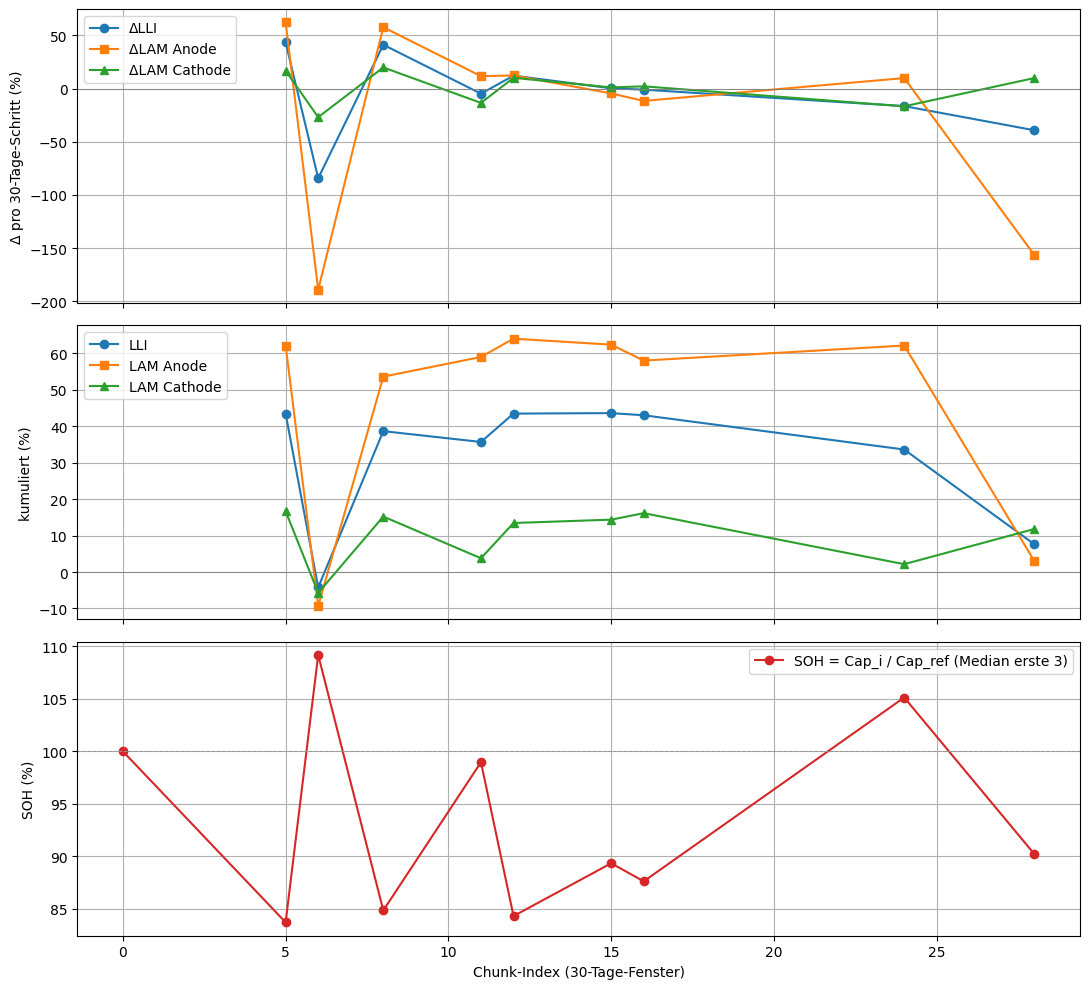

In [60]:
if cum_df.empty:
    print("Keine LLI/LAM-Zeitreihe (zu wenige plausible Chunks) — es wird nur der SOH-Verlauf geplottet.")
    fig, ax_soh = plt.subplots(figsize=(11, 4))
else:
    fig, (ax_roll, ax_cum, ax_soh) = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

    x_roll = rolling_df["chunk"].to_numpy()
    ax_roll.plot(x_roll, rolling_df["LLI_pct"],         "o-", label="ΔLLI",          color="tab:blue")
    ax_roll.plot(x_roll, rolling_df["LAM_Anode_pct"],   "s-", label="ΔLAM Anode",    color="tab:orange")
    ax_roll.plot(x_roll, rolling_df["LAM_Cathode_pct"], "^-", label="ΔLAM Cathode",  color="tab:green")
    ax_roll.axhline(0, color="0.5", lw=0.6)
    ax_roll.set_ylabel("Δ pro 30-Tage-Schritt (%)")
    ax_roll.grid(True); ax_roll.legend()

    x_cum = cum_df["chunk"].to_numpy()
    ax_cum.plot(x_cum, cum_df["LLI_pct"],         "o-", label="LLI",         color="tab:blue")
    ax_cum.plot(x_cum, cum_df["LAM_Anode_pct"],   "s-", label="LAM Anode",   color="tab:orange")
    ax_cum.plot(x_cum, cum_df["LAM_Cathode_pct"], "^-", label="LAM Cathode", color="tab:green")
    ax_cum.axhline(0, color="0.5", lw=0.6)
    ax_cum.set_ylabel("kumuliert (%)")
    ax_cum.grid(True); ax_cum.legend()

x_all   = np.array(soh_ids)
soh_all = np.array([cap_per_chunk_mAh[i] / CAP_REF_mAh * 100 for i in soh_ids])
ax_soh.plot(x_all, soh_all, "o-", color="tab:red", label="SOH = Cap_i / Cap_ref (Median erste 3)")
ax_soh.axhline(100, color="0.6", lw=0.7, ls="--")
ax_soh.set_xlabel("Chunk-Index (30-Tage-Fenster)")
ax_soh.set_ylabel("SOH (%)")
ax_soh.grid(True); ax_soh.legend()

plt.tight_layout()
plt.show()

### C.7b) SOH-Verlauf mit Wurzel-Trend



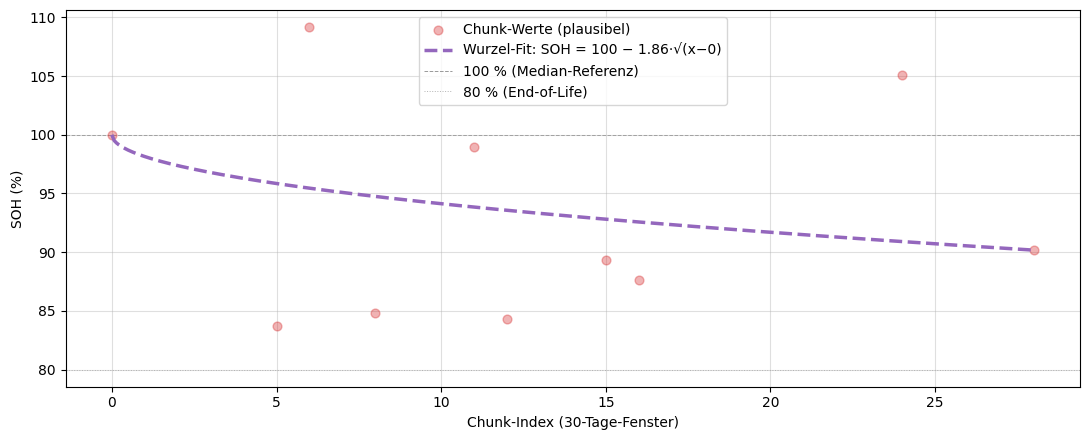

Trend-Hub: 9.8 Pp | Chunk-Streuung um den Fit: ±8.8 Pp
Prognose End-of-Life (SOH 80 %): Chunk 116.0  (~3480 Tage)


In [61]:
from scipy.optimize import curve_fit

x = np.array(soh_ids, dtype=float)
y = np.array([cap_per_chunk_mAh[i] / CAP_REF_mAh * 100 for i in soh_ids])

if len(x) < 4:
    print(f"Nur {len(x)} plausible Chunks — zu wenig fuer einen belastbaren Trend-Fit.")
else:
    # Wurzel-Alterungsmodell, fest bei 100 % verankert: SOH(x) = 100 - b * sqrt(x - x0)
    x0 = x.min()
    def sqrt_model(xx, b):
        return 100.0 - b * np.sqrt(xx - x0)

    (b,), _ = curve_fit(sqrt_model, x, y, p0=[1.0])
    x_fine = np.linspace(x.min(), x.max(), 400)
    y_fit  = sqrt_model(x_fine, b)

    trend_span = abs(sqrt_model(x.max(), b) - 100.0)          # Trend-Hub ueber den Zeitraum
    noise      = float(np.std(y - sqrt_model(x, b)))          # Chunk-Streuung um den Fit

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.scatter(x, y, color="tab:red", alpha=0.35, s=40, zorder=2,
               label="Chunk-Werte (plausibel)")
    ax.plot(x_fine, y_fit, "--", color="tab:purple", lw=2.5, zorder=3,
            label=f"Wurzel-Fit: SOH = 100 − {b:.2f}·√(x−{x0:.0f})")
    ax.axhline(100, color="0.6", lw=0.7, ls="--", zorder=1,
               label="100 % (Median-Referenz)")
    ax.axhline(80, color="0.7", lw=0.7, ls=":", zorder=1,
               label="80 % (End-of-Life)")
    ax.set_xlabel("Chunk-Index (30-Tage-Fenster)")
    ax.set_ylabel("SOH (%)")
    ax.grid(True, alpha=0.4)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

    print(f"Trend-Hub: {trend_span:.1f} Pp | Chunk-Streuung um den Fit: ±{noise:.1f} Pp")
    if b <= 0:
        print("Kein degradierender Trend (b ≤ 0) — keine EOL-Prognose moeglich.")
    elif noise >= trend_span:
        x_eol = x0 + (20.0 / b) ** 2
        print(f"EOL-Rechenwert (SOH 80 %): Chunk {x_eol:.1f} (~{x_eol*30:.0f} Tage) — "
              f"NICHT belastbar: Streuung (±{noise:.1f} Pp) ≥ Trend-Hub ({trend_span:.1f} Pp).")
    else:
        x_eol = x0 + (20.0 / b) ** 2
        print(f"Prognose End-of-Life (SOH 80 %): Chunk {x_eol:.1f}  (~{x_eol*30:.0f} Tage)")

---
# Synthese — drei Pipelines auf einem Blick



In [62]:
_real = cum_df.iloc[-1] if not cum_df.empty else None
synth = pd.DataFrame({
    "iOCV (B1→B2)":          [lli_lam_iocv["SOH_pct"].iloc[0],
                              lli_lam_iocv["LLI_pct"].iloc[0],
                              lli_lam_iocv["LAM_Anode_pct"].iloc[0],
                              lli_lam_iocv["LAM_Cathode_pct"].iloc[0]],
    "FUDS (B1→B2)":          [lli_lam_fuds["SOH_pct"].iloc[0],
                              lli_lam_fuds["LLI_pct"].iloc[0],
                              lli_lam_fuds["LAM_Anode_pct"].iloc[0],
                              lli_lam_fuds["LAM_Cathode_pct"].iloc[0]],
    "Realdaten (kumulativ Endwert)": [
        float(_real["SOH_pct"])         if _real is not None else float("nan"),
        float(_real["LLI_pct"])         if _real is not None else float("nan"),
        float(_real["LAM_Anode_pct"])   if _real is not None else float("nan"),
        float(_real["LAM_Cathode_pct"]) if _real is not None else float("nan"),
    ],
}, index=["SOH_pct", "LLI_pct", "LAM_Anode_pct", "LAM_Cathode_pct"]).round(2)
synth

,iOCV (B1→B2),FUDS (B1→B2),Realdaten (kumulativ Endwert)
SOH_pct,99.92,95.93,90.21
LLI_pct,1.14,3.92,7.60
LAM_Anode_pct,-0.01,4.62,2.99
LAM_Cathode_pct,1.43,3.62,11.81
